# *Correlation Heatmap & Pairwise Relationships*

## *Load and Inspect*

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("Housing.csv")
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [5]:
# selecting numeric datatypes for correlation
num_df = df[['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']]
num_df = num_df.dropna()
num_df.head()

,price,area,bedrooms,bathrooms,stories,parking
0,13300000,7420,4,2,3,2
1,12250000,8960,4,4,4,3
2,12250000,9960,3,2,2,2
3,12215000,7500,4,2,2,3
4,11410000,7420,4,1,2,2


## *Correlation*

In [6]:
# num_df.corr().style.background_gradient(cmap='coolwarm') -- For colored background

corr_mat = num_df.corr()
corr_mat

,price,area,bedrooms,bathrooms,stories,parking
price,1.000000,0.535997,0.366494,0.517545,0.420712,0.384394
area,0.535997,1.000000,0.151858,0.193820,0.083996,0.352980
bedrooms,0.366494,0.151858,1.000000,0.373930,0.408564,0.139270
bathrooms,0.517545,0.193820,0.373930,1.000000,0.326165,0.177496
stories,0.420712,0.083996,0.408564,0.326165,1.000000,0.045547
parking,0.384394,0.352980,0.139270,0.177496,0.045547,1.000000


## *Heatmap*

In [7]:
# To remove redundancy
import numpy as np

mask = np.triu(np.ones_like(corr_mat, dtype=bool))

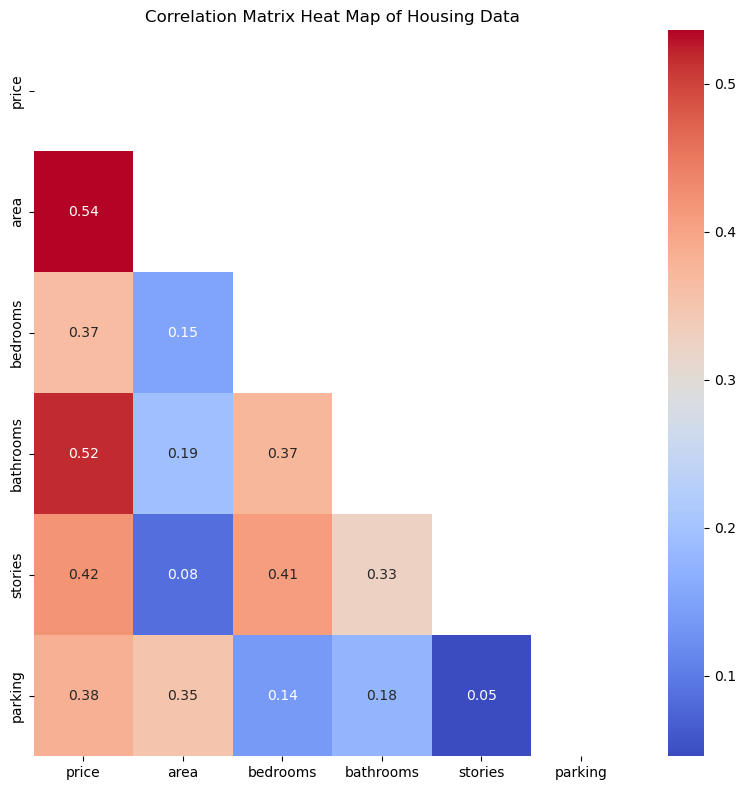

In [8]:
plt.figure(figsize=(8,8))
sns.heatmap(corr_mat,
            mask=mask, annot=True, 
            cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix Heat Map of Housing Data")
plt.tight_layout()
plt.savefig("heatmap.png")
plt.show()

## *Pairplot for Key Variable Pairs*

In [9]:
num_df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking'], dtype='object')

In [10]:
num_df['stories'] = num_df['stories'].astype('category')

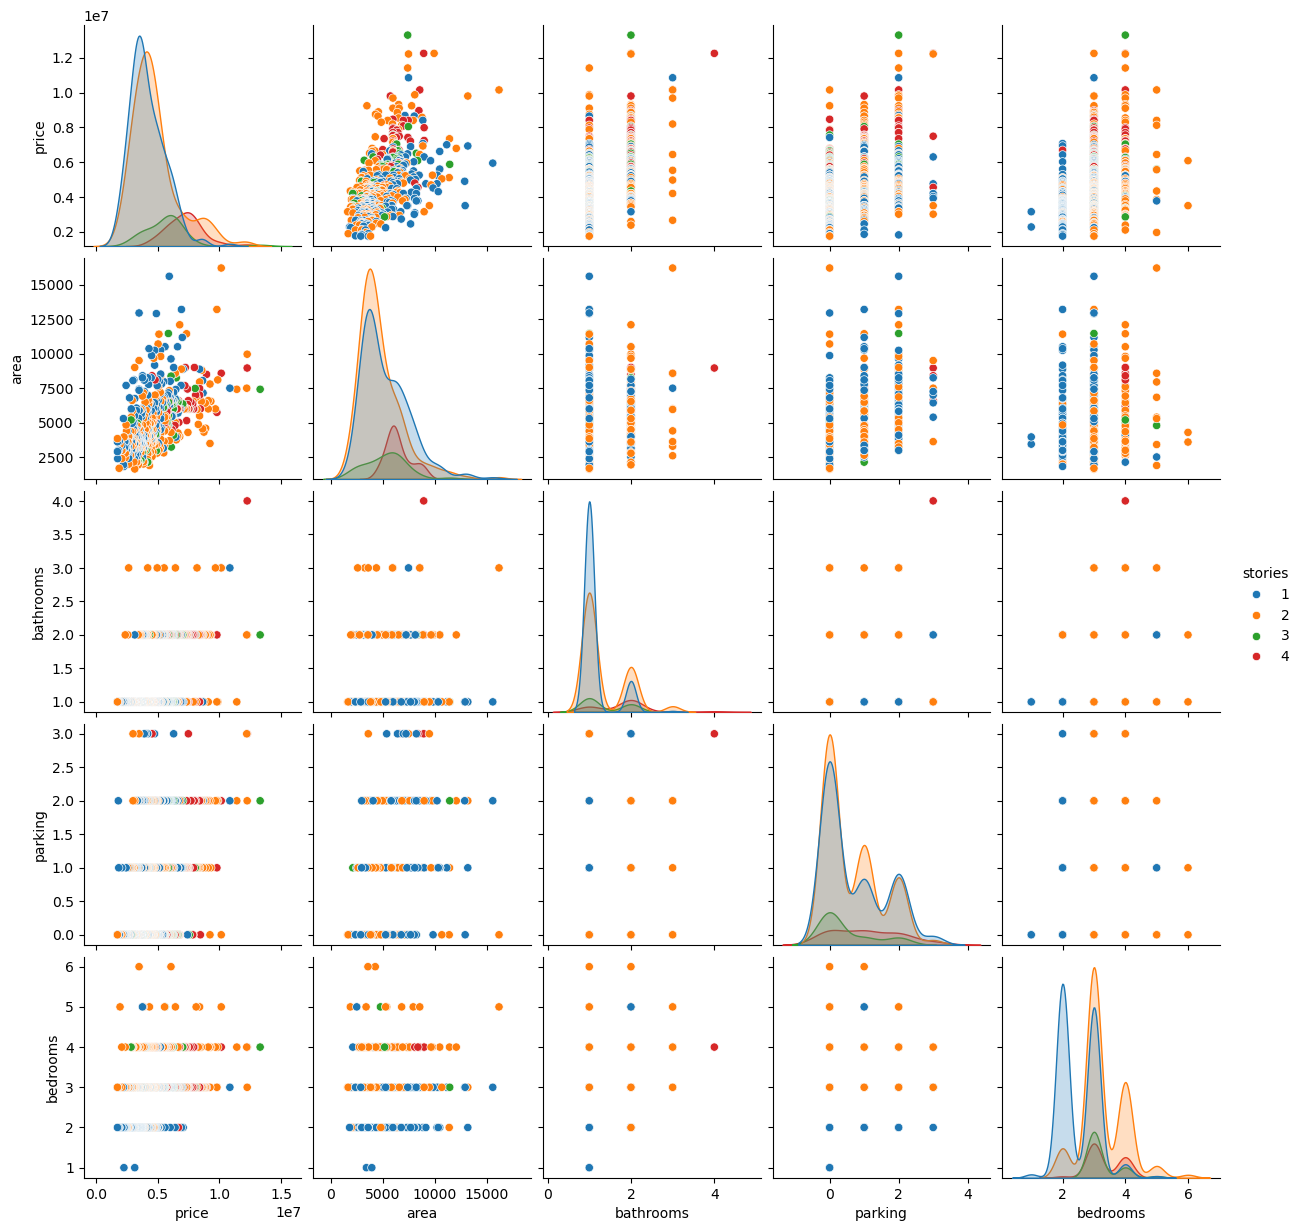

In [11]:
key_cols = ['price', 'area', 'bathrooms', 'stories', 'parking', 'bedrooms']
sns.pairplot(num_df[key_cols], hue='stories')
plt.savefig("pairplot.png")

## *Summary of Relationships*

- Price and area show the strongest relationship with r = 0.54, suggesting the larger the property area, the higher the price.
- From the pairplot, it is noted that the number of stories resulted in an increase in price, regardless of the bedroom numbers.
- Bathrooms, parking, and bedrooms show a stronger relationship with the price of the house, with correlations with price being r = 0.52, 0.38, 0.42 respectively, suggesting the higher these features, the higher the prices get.
- Stories and parking have the least correlation, suggesting change in any of them does not affect the other directly. They are poor predictors of each other. Same can be noted for bedrooms and area, bathrooms and area, stories and area, parking and bedrooms, and, parking and bathrooms.
- While the correlation between some is higher than others, all the fields correlate positively, which suggests that all the fields move in the same direction, and there are no competing fields within the housing dataset.